In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("CC GENERAL.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (8950, 18)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [7]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8950, 18)


In [10]:
customer_ids = df["CUST_ID"].copy()

df = df.drop(columns=["CUST_ID"])

In [11]:
missing_before = df.isnull().sum()

missing_before[missing_before > 0]

,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313


In [12]:
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df_original = df.copy()

In [15]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [16]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns,
    index=df.index
)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [17]:
inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia_values.append(kmeans.inertia_)

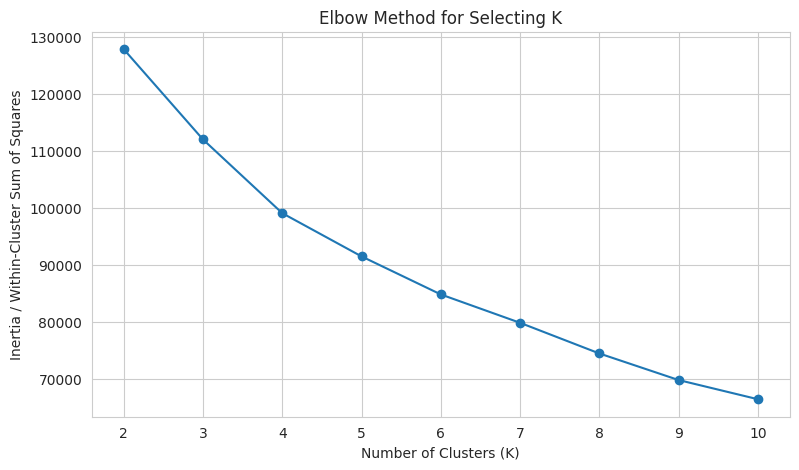

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Selecting K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / Within-Cluster Sum of Squares")
plt.xticks(list(k_values))
plt.show()

In [19]:
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)

In [20]:
silhouette_table = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_scores
})

silhouette_table

,K,Inertia,Silhouette Score
0,2,127784.534545,0.210043
1,3,111975.043593,0.250988
2,4,99061.939842,0.197679
3,5,91490.498040,0.193112
4,6,84826.592031,0.202860
5,7,79856.157018,0.207686
6,8,74484.880062,0.221698
7,9,69828.699269,0.226034
8,10,66466.414929,0.220438


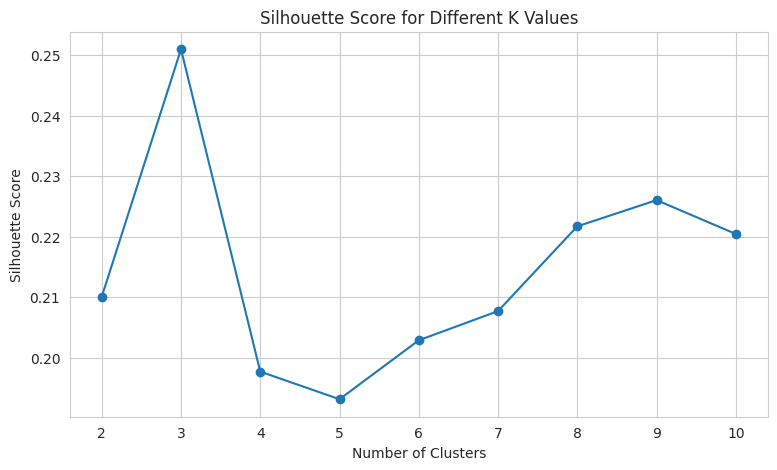

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

In [22]:
best_k = silhouette_table.loc[
    silhouette_table["Silhouette Score"].idxmax(),
    "K"
]

print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 3


In [23]:
selected_k = 4

In [24]:
selected_k = 4

In [25]:
kmeans_model = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(scaled_data)

In [26]:
df_original["KMeans_Cluster"] = kmeans_labels

In [27]:
kmeans_counts = df_original[
    "KMeans_Cluster"
].value_counts().sort_index()

kmeans_counts

,count
KMeans_Cluster,
0,3977
1,409
2,1197
3,3367


In [28]:
kmeans_silhouette = silhouette_score(
    scaled_data,
    kmeans_labels
)

print(
    "K-Means silhouette score:",
    round(kmeans_silhouette, 4)
)

K-Means silhouette score: 0.1977


In [29]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [30]:
pca_df = pd.DataFrame({
    "PCA1": pca_data[:, 0],
    "PCA2": pca_data[:, 1],
    "KMeans_Cluster": kmeans_labels
})

In [31]:
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total variance explained by two components:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

Explained variance ratio: [0.27297671 0.2031378 ]
Total variance explained by two components: 0.4761


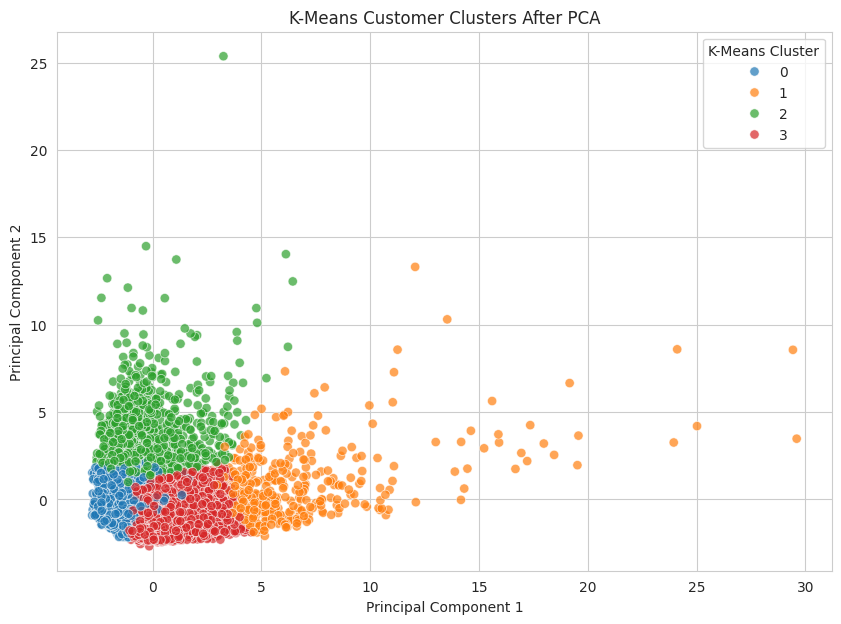

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    palette="tab10",
    s=45,
    alpha=0.7
)

plt.title("K-Means Customer Clusters After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.show()

In [33]:
kmeans_profile = df_original.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

kmeans_profile.round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,1012.66,0.79,270.04,209.94,60.37,596.51,0.17,0.09,0.08,0.11,2.13,2.90,3278.64,974.26,553.90,0.08,11.45
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1972.77,0.29,11.95
2,4602.45,0.97,501.86,320.19,181.76,4521.51,0.29,0.14,0.19,0.48,14.29,7.67,7546.16,3484.05,2003.67,0.03,11.39
3,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,639.68,0.27,11.59


In [34]:
important_features = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT",
    "TENURE"
]

kmeans_summary = (
    df_original
    .groupby("KMeans_Cluster")[important_features]
    .mean()
    .round(2)
)

kmeans_summary

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,
0,1012.66,270.04,209.94,60.37,596.51,3278.64,974.26,553.90,0.17,0.11,0.08,11.45
1,3551.15,7681.62,5095.88,2587.21,653.64,9696.94,7288.74,1972.77,0.95,0.07,0.29,11.95
2,4602.45,501.86,320.19,181.76,4521.51,7546.16,3484.05,2003.67,0.29,0.48,0.03,11.39
3,894.91,1236.18,593.97,642.48,210.57,4213.21,1332.19,639.68,0.89,0.04,0.27,11.59


In [35]:
kmeans_summary["Customer_Count"] = (
    df_original
    .groupby("KMeans_Cluster")
    .size()
)

kmeans_summary

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE,Customer_Count
KMeans_Cluster,,,,,,,,,,,,,
0,1012.66,270.04,209.94,60.37,596.51,3278.64,974.26,553.90,0.17,0.11,0.08,11.45,3977
1,3551.15,7681.62,5095.88,2587.21,653.64,9696.94,7288.74,1972.77,0.95,0.07,0.29,11.95,409
2,4602.45,501.86,320.19,181.76,4521.51,7546.16,3484.05,2003.67,0.29,0.48,0.03,11.39,1197
3,894.91,1236.18,593.97,642.48,210.57,4213.21,1332.19,639.68,0.89,0.04,0.27,11.59,3367


In [36]:
overall_average = df_original[
    important_features
].mean()

relative_kmeans_profile = (
    kmeans_summary[important_features]
    .divide(overall_average)
)

relative_kmeans_profile.round(2)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,
0,0.65,0.27,0.35,0.15,0.61,0.73,0.56,0.66,0.35,0.81,0.52,0.99
1,2.27,7.66,8.60,6.29,0.67,2.16,4.21,2.33,1.94,0.52,1.89,1.04
2,2.94,0.50,0.54,0.44,4.62,1.68,2.01,2.37,0.59,3.55,0.20,0.99
3,0.57,1.23,1.00,1.56,0.22,0.94,0.77,0.76,1.82,0.30,1.76,1.01


In [38]:
dbscan_model = DBSCAN(
    eps=1.8,
    min_samples=10
)

dbscan_labels = dbscan_model.fit_predict(scaled_data)

In [39]:
unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dbscan_counts = pd.DataFrame({
    "Cluster": unique_labels,
    "Customer_Count": counts
})

dbscan_counts

,Cluster,Customer_Count
0,-1,957
1,0,7993


In [40]:
number_of_clusters = len(
    set(dbscan_labels) - {-1}
)

number_of_noise_points = np.sum(
    dbscan_labels == -1
)

print("Number of DBSCAN clusters:", number_of_clusters)
print("Number of noise points:", number_of_noise_points)

Number of DBSCAN clusters: 1
Number of noise points: 957


In [41]:
non_noise_mask = dbscan_labels != -1

non_noise_labels = dbscan_labels[
    non_noise_mask
]

if len(np.unique(non_noise_labels)) >= 2:

    dbscan_silhouette = silhouette_score(
        scaled_data[non_noise_mask],
        non_noise_labels
    )

    print(
        "DBSCAN silhouette score:",
        round(dbscan_silhouette, 4)
    )

else:
    dbscan_silhouette = np.nan

    print(
        "Silhouette score cannot be calculated because "
        "DBSCAN produced fewer than two non-noise clusters."
    )

Silhouette score cannot be calculated because DBSCAN produced fewer than two non-noise clusters.


In [42]:
dbscan_pca_df = pd.DataFrame({
    "PCA1": pca_data[:, 0],
    "PCA2": pca_data[:, 1],
    "DBSCAN_Cluster": dbscan_labels
})

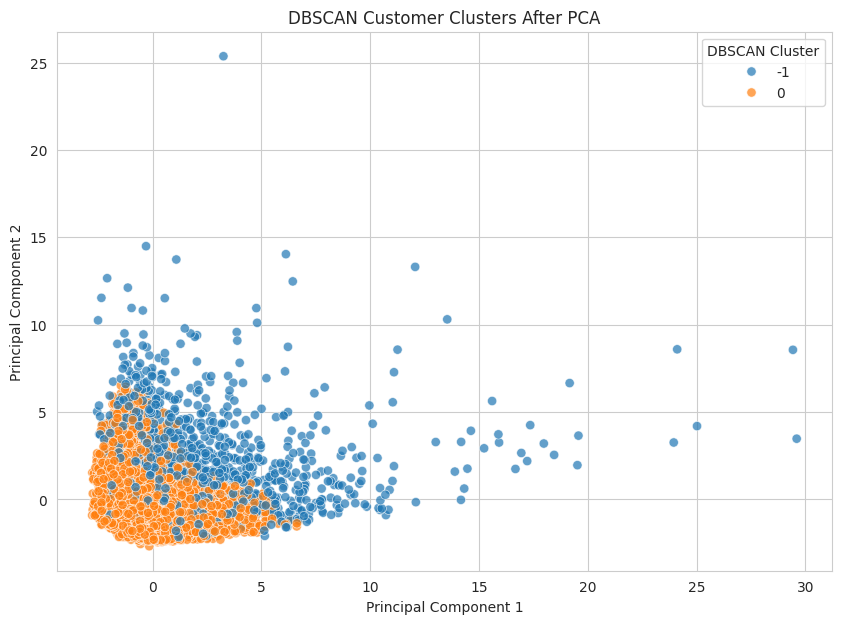

In [43]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=dbscan_pca_df,
    x="PCA1",
    y="PCA2",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=45,
    alpha=0.7
)

plt.title("DBSCAN Customer Clusters After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")
plt.show()

In [44]:
df_original["DBSCAN_Cluster"] = dbscan_labels

In [45]:
dbscan_summary = (
    df_original
    .groupby("DBSCAN_Cluster")[important_features]
    .mean()
    .round(2)
)

dbscan_summary["Customer_Count"] = (
    df_original
    .groupby("DBSCAN_Cluster")
    .size()
)

dbscan_summary

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE,Customer_Count
DBSCAN_Cluster,,,,,,,,,,,,,
-1,3958.07,3641.17,2352.71,1289.11,3307.33,8899.08,6055.20,2833.38,0.67,0.29,0.19,11.23,957
0,1277.89,687.36,381.68,305.94,700.08,3966.90,1215.67,606.83,0.47,0.12,0.15,11.55,7993


In [46]:
dbscan_experiments = []

for eps_value in [
    0.8,
    1.0,
    1.2,
    1.5,
    1.8,
    2.0,
    2.5
]:

    model = DBSCAN(
        eps=eps_value,
        min_samples=10
    )

    labels = model.fit_predict(scaled_data)

    clusters = len(set(labels) - {-1})
    noise_points = np.sum(labels == -1)

    non_noise = labels != -1

    if clusters >= 2:
        score = silhouette_score(
            scaled_data[non_noise],
            labels[non_noise]
        )
    else:
        score = np.nan

    dbscan_experiments.append({
        "eps": eps_value,
        "Number of Clusters": clusters,
        "Noise Points": noise_points,
        "Noise Percentage": (
            noise_points / len(labels)
        ) * 100,
        "Silhouette Score": score
    })

In [47]:
dbscan_parameter_results = pd.DataFrame(
    dbscan_experiments
)

dbscan_parameter_results.round(4)

,eps,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
0,0.8,7,4925,55.0279,0.0669
1,1.0,3,3632,40.5810,0.3095
2,1.2,1,2564,28.6480,NaN
3,1.5,1,1561,17.4413,NaN
4,1.8,1,957,10.6927,NaN
5,2.0,1,710,7.9330,NaN
6,2.5,1,386,4.3128,NaN


In [48]:
comparison_results = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN"
    ],

    "Number of Clusters": [
        len(np.unique(kmeans_labels)),
        len(set(dbscan_labels) - {-1})
    ],

    "Noise Points": [
        0,
        np.sum(dbscan_labels == -1)
    ],

    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

comparison_results.round(4)

,Algorithm,Number of Clusters,Noise Points,Silhouette Score
0,K-Means,4,0,0.1977
1,DBSCAN,1,957,NaN


In [49]:
relative_profile = (
    df_original
    .groupby("KMeans_Cluster")[important_features]
    .mean()
    .divide(
        df_original[important_features].mean()
    )
)

for cluster_number in relative_profile.index:

    cluster_values = relative_profile.loc[
        cluster_number
    ]

    highest_features = (
        cluster_values
        .sort_values(ascending=False)
        .head(3)
    )

    lowest_features = (
        cluster_values
        .sort_values()
        .head(3)
    )

    print(f"\nK-Means Cluster {cluster_number}")

    print("\nHighest relative characteristics:")
    print(highest_features.round(2))

    print("\nLowest relative characteristics:")
    print(lowest_features.round(2))


K-Means Cluster 0

Highest relative characteristics:
TENURE                    0.99
CASH_ADVANCE_FREQUENCY    0.85
CREDIT_LIMIT              0.73
Name: 0, dtype: float64

Lowest relative characteristics:
INSTALLMENTS_PURCHASES    0.15
PURCHASES                 0.27
PURCHASES_FREQUENCY       0.35
Name: 0, dtype: float64

K-Means Cluster 1

Highest relative characteristics:
ONEOFF_PURCHASES          8.60
PURCHASES                 7.66
INSTALLMENTS_PURCHASES    6.29
Name: 1, dtype: float64

Lowest relative characteristics:
CASH_ADVANCE_FREQUENCY    0.53
CASH_ADVANCE              0.67
TENURE                    1.04
Name: 1, dtype: float64

K-Means Cluster 2

Highest relative characteristics:
CASH_ADVANCE              4.62
CASH_ADVANCE_FREQUENCY    3.59
BALANCE                   2.94
Name: 2, dtype: float64

Lowest relative characteristics:
PRC_FULL_PAYMENT          0.23
INSTALLMENTS_PURCHASES    0.44
PURCHASES                 0.50
Name: 2, dtype: float64

K-Means Cluster 3

Highest relati